#**Chapter4. 모델훈련**
 모델구현을 하는 과정에서 어떻게 작동하는지 이해하는 과정에 대해서 배우게 될것.

##**4.1 선형회귀**
일반적으로 선형모델은 입력 특성의 가중치과 편향이라는 상수를 더해 예측을 만듦. 선형회귀 모델을 훈련시키려면 RMSE를 최소화하는 세타를 찾아야 함.  

###4.1.1. 정규방정식
비용함수를 최소화하는 세타값을 찾기 위한 해석적인 방법으로는 정규방정식이 있음.  

In [1]:
import numpy as np

X = 2*np.random.rand(100,1)
y = 4+3*X+np.random.randn(100,1)

In [2]:
X_b = np.c_[np.ones((100,1)), X]
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

In [3]:
theta_best

array([[4.20623102],
       [2.85751137]])

In [4]:
X_new = np.array([[0],[2]])
X_new_b = np.c_[np.ones((2,1)), X_new]
y_predict = X_new_b.dot(theta_best)
y_predict

array([[4.20623102],
       [9.92125376]])

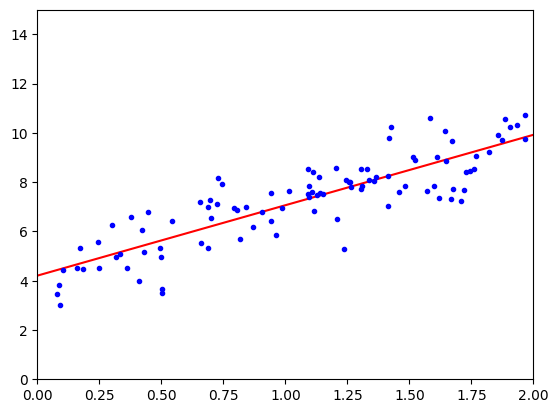

In [6]:
import matplotlib.pyplot as plt

plt.plot(X_new, y_predict, "r-")
plt.plot(X,y,"b.")
plt.axis([0,2,0,15])
plt.show()

In [7]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X,y)

LinearRegression()

In [8]:
lin_reg.intercept_, lin_reg.coef_

(array([4.20623102]), array([[2.85751137]]))

In [9]:
lin_reg.predict(X_new)

array([[4.20623102],
       [9.92125376]])

In [10]:
theta_best_svd, residuals, rank, s =np.linalg.lstsq(X_b,y,rcond=1e-6)
theta_best_svd

array([[4.20623102],
       [2.85751137]])

In [11]:
np.linalg.pinv(X_b).dot(y)

array([[4.20623102],
       [2.85751137]])

np.linalg.pinv()함수를 사용해 유사역행렬을 직접 구할 수 있음. 유사역행렬 자체는 특잇값 분해라 부르는 표준 행렬 분해 기법을 사용해 계산함.

###4.1.2. 계산복잡도
역행렬을 계산하는 계산복잡도는 일반적으로 o(n2.4)에서 o(n3)사이.

##**4.2 경사 하강법**
경사하강법은 여러 종류의 문제에서 최적의 해법을 찾을 수 있는 일반적인 최적화 알고리즘. 기본 아이디어는 비용함수를 최소화하기 위해 반복해서 파라미터를 조정해가는 것.

파라미터 벡타(세타)에 대해 비용함수의 현재 그레이디언트를 계산하고 이가 감소하는 방향으로 진행.

경사하강법에서 중요한 파라미터는 스텝의 크기로 학습률 하이퍼 파라미터로 결정됨.

###4.2.1. 배치 경사 하강법
모델 파라미터(세타)가 조금 변경될 때 비용함수가 얼마나 바뀌는지 계산하는 편도함수.

In [12]:
eta = 0.1
n_iterations = 1000
m=100

theta = np.random.randn(2,1)

for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta)-y)
    theta = theta - eta*gradients

In [13]:
theta

array([[4.20623102],
       [2.85751137]])

적절한 학습률을 찾으려면 그리드 탐색을 사용함. 하지만 그리드 탐색에서 수렴하는 데 너무 오래 걸리는 모델을 막기 위해 반복 횟수를 제한해야 함.

###4.2.2. 확률적 경사 하강법
확률적 경사 하강법은 매 스텝에서 한개의 샘플을 무작위로 선택하고 그 하나의 샘플에 대한 그레이디언트를 계산. 학습률을 점진적으로 감소시켜야 확률적 경사 하강법의 단점을 해결할 수 있음.

In [15]:
n_epochs = 50
t0, t1 = 5,50

def learning_schedule(t):
    return t0/ (t+t1)

theta = np.random.randn(2,1)

for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index : random_index+1]
        gradients = 2*xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule (epoch*m +i)
        theta = theta - eta*gradients

In [16]:
theta

array([[4.14063788],
       [2.86547375]])

In [18]:
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter = 1000, tol=1e-3, penalty = None, eta0= 0.1)
sgd_reg.fit(X,y.ravel())

SGDRegressor(eta0=0.1, penalty=None)

In [19]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.15425867]), array([2.85751744]))

###4.2.3 미니배치 경사 하강법
미니배치라 부르는 임의의 작음 샘플 세트에 대해 그레이디언트를 계산. 미니 배치 경사 하강법의 주요 장점은 행렬 연산에 최적화된 하드웨어, 특히 GPU를 사용해서 얻는 성능향상임.

##**4.3 다항 회귀**
각 특성의 거듭제곱을 새로운 특성으로 추가하고, 이 확장된 특성을 포함한 데이터 셋에 선형 모델을 훈련시키는 것.

In [20]:
m = 100
X = 6*np.random.rand(m,1)-3
y = 0.5 * X**2 + X + 2+ np.random.randn(m,1)

In [21]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias = False)
X_poly = poly_features.fit_transform(X)
X[0]

array([-1.54912543])

In [22]:
X_poly[0]

array([-1.54912543,  2.39978961])

In [23]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly,y)
lin_reg.intercept_, lin_reg.coef_

(array([2.23001874]), array([[0.9824535 , 0.45395216]]))

##**4.4 학습곡선**
고차 다항 회귀를 적용하면 보통의 선형 회귀에서보다 훨씬 더 훈련 데이터에 잘 맞추려 할 것임. 이 때 학습곡선은 훈련 세트와 검증 세트의 모델 성능을 훈련 세트 크기의 함수로 나타냄.

In [26]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_learning_curves(model,X,y):
  X_train, X_val, y_train, y_val = train_test_split(X,y,test_size = 0.2)
  train_errors, val_errors = [],[]
  for m in range(1, len(X_train)):
    model.fit(X_train[:m], y_train[:m])
    y_train_predict = model.predict(X_train[:m])
    y_val_predict = model.predict(X_val)
    train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
    val_errors.append(mean_squared_error(y_val, y_val_predict))
  plt.plot(np.sqrt(train_errors), 'r-+', linewidth=2, label = 'train set')
  plt.plot(np.sqrt(val_errors), 'b--', linewidth=3, label = 'test set')
  plt.ylim(0,3)
  plt.legend()
  plt.show()

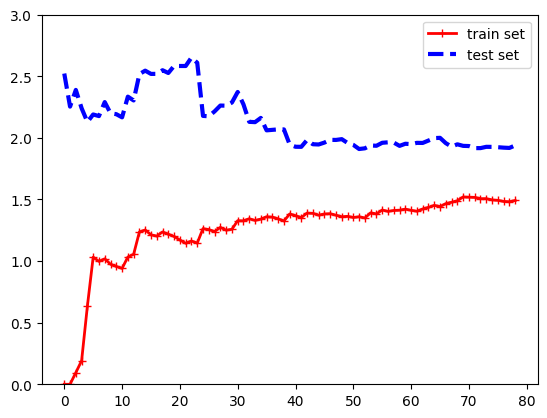

In [27]:
lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X,y)

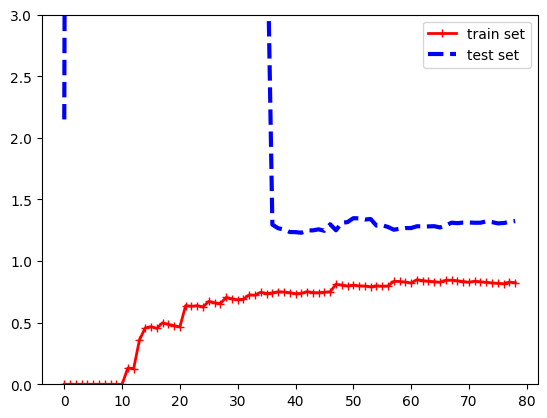

In [28]:
from sklearn.pipeline import Pipeline

polynomial_regression = Pipeline([
    ('poly_features', PolynomialFeatures(degree=10, include_bias = False)),
    ('lin_reg', LinearRegression())
])

plot_learning_curves(polynomial_regression, X, y)


##**4.5 규제가 있는 선형 모델**
과대적합을 감소시키는 좋은 방법은 모델을 규제하는 것.

###4.5.1 릿지 회귀
릿지회귀는 규제가 추가된 선형 회귀 버전. 규제항이 비용함수에 추가됨.

In [29]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=1, solver="cholesky")
ridge_reg.fit(X,y)
ridge_reg.predict([[1.5]])

array([[5.04110073]])

In [30]:
sgd_reg = SGDRegressor(penalty="l2")
sgd_reg.fit(X,y.ravel())
sgd_reg.predict([[1.5]])

array([5.00945551])

###4.5.2 라쏘 회귀
라쏘 회귀는 선형 회귀의 또 다른 규제된 버전. 릿지 회귀처럼 비용함수에 규제항을 더하지만 l2노름의 제곰을 2로 나눈 것 대신 가중치 벡터의 l1노름을 사용.

In [31]:
from sklearn. linear_model import Lasso
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X,y)
lasso_reg.predict([[1.5]])

array([4.98973007])

###4.5.3 엘라스틱넷
엘라스틱넷은 릿지회귀와 라쏘회귀를 절충한 모델. 규제항은 릿지와 회귀의 규제항을 단순히 더해서 사용하며, 혼합정도는 혼합비율 r을 이용해 조절.

In [32]:
from sklearn. linear_model import ElasticNet
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X,y)
elastic_net.predict([[1.5]])

array([4.99347564])

###4.5.4 조기 종료
반복적인 학습 알고리즘을 규제하는 아주 색다른 방식은 검증에러가 최솟값에 도달하면 바로 훈련을 중지시키는 것.

In [33]:
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler

#데이터 준비
poly_scaler = Pipeline([
    ('poly_features', PolynomialFeatures(degree=90, include_bias = False)),
    ('std_scaler', StandardScaler())
])

X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=0.2)
X_train_poly_scaled = poly_scaler.fit_transform(X_train)
X_val_poly_scaled = poly_scaler.transform(X_val)

sgd_reg = SGDRegressor(max_iter=1, tol=None, warm_start=True,
                       penalty=None, learning_rate="constant", eta0=0.0005)

minimum_val_error = float('inf')
best_epoch = None
best_model = None
for epoch in range(1000):
  sgd_reg.fit(X_train_poly_scaled,y_train.ravel())   #훈련을 이어서 진행합니다.
  y_val_predict = sgd_reg.predict(X_val_poly_scaled)
  val_error = mean_squared_error(y_val, y_val_predict)
  if val_error < minimum_val_error:
    minimum_val_error = val_error
    best_epoch = epoch
    best_model = clone(sgd_reg)

##**4.6 로지스틱 회귀**
로지스틱회귀는 샘플이 특정 클래스에 속할 확률을 추정하는 데 널리 사용됨.

###4.6.1 확률 추정
선형 회귀 모델과 같이 로지스틱 회귀 모델은 입력 특성의 가중치 합을 계산. 대신 바로 결과를 출력하지 않고 결괏값의 로지스틱을 출력.

###4.6.2 훈련과 비용함수
양성 샘플(y=1)에 대해서는 높은 확률 추정, 음성 샘플(y=0)에 대해서는 낮은 확률 추정을 하는 파라미터를 찾음.

###4.6.3 결정 경계


In [34]:
from sklearn import datasets
iris = datasets.load_iris()
list(iris.keys())

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [36]:
X = iris["data"][:,3:]
y = (iris["target"]==2).astype(int)

In [37]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X,y)

LogisticRegression()

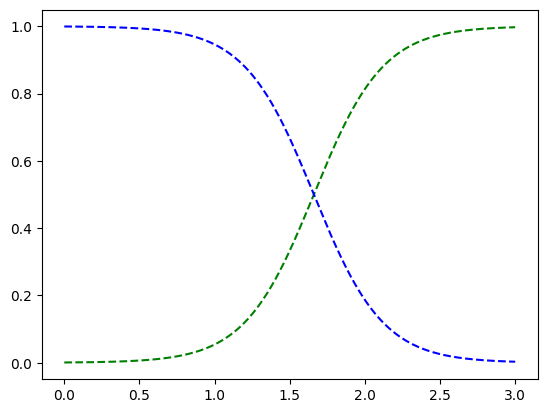

In [38]:
X_new = np.linspace(0,3,1000).reshape(-1,1)
y_proba = log_reg.predict_proba(X_new)
plt.plot(X_new, y_proba[:, 1], 'g--', label = 'Iris virinica')
plt.plot(X_new, y_proba[:,0], 'b--', label = "Not Iris virginica")

In [39]:
log_reg.predict([[1.7],[1.5]])

array([1, 0])

###4.6.4 소프트맥스 회귀
로지스틱 회귀 모델은 여러 개의 이진분류기를 훈련시켜 연결하지 않고 직접 다중 클래스를 지원하도록 일반화될 수 있음. 이를 소프트맥스 회귀, 다향 로지스틱 회귀라고 함.

In [40]:
X = iris["data"][:,(2,3)]
y = iris["target"]

softmax_reg = LogisticRegression(multi_class="multinomial", solver="lbfgs", C=10)
softmax_reg.fit(X,y)

LogisticRegression(C=10, multi_class='multinomial')

In [42]:
softmax_reg.predict([[5,2]])

array([2])

In [43]:
softmax_reg.predict_proba([[5,2]])

array([[6.38014896e-07, 5.74929995e-02, 9.42506362e-01]])